In [40]:
import scipy.io as sio
import fig_toolbox as fig_tb
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import importlib
importlib.reload(fig_tb)

<module 'fig_toolbox' from '/Users/Kary/Library/Mobile Documents/com~apple~CloudDocs/Projects/psyc-pathology-main/python_code/fig_toolbox.py'>

In [41]:
config = defaultdict()
# === Global Plot Settings ===
config['TITLE'] = None
config['XLIM'] = None
config['X_TICK_LABEL'] = None
config['XLABEL'] = None
config['YLIM'] = None
config['Y_TICK_LABEL'] = None
config['YLABEL'] = None 

config['LEGEND_LOC'] = 'best'
config['LEGEND_TITLE'] = None
config['SHOW_LEGEND'] = True    
config['GROUP_LABEL'] = None
size_colors = ['#5B84B1', '#D9A441'] # Small, Large
factor_colors = ['#2A9D8F', '#E76F51', '#5A5A5A'] # Internalizing, Externalizing, Difference
eff_colors = ["#488714DB", "#18843AD6", "#862222D0"]  # Baseline LR, Stochasticity, Volatility
group_colors = ["#8FBFA5", "#BFD8DD", "#DBB6A2FF"] # Sto-blind, Intact, Vol-blind
config['CAPSIZE'] = 0
config['BAR_ALPHA'] = 0.7
config['BAR_WIDTH'] = 0.2
config['BAR_SPACING'] = 0.25
config['LINE_ALPHA'] = 0.3
config['LINE_WIDTH'] = 2

config['TITLE_FONTSIZE'] = 14
config['LABEL_FONTSIZE'] = 12
config['TICK_FONTSIZE'] = 10
config['LEGEND_FONTSIZE'] = 11

config['SAVE_PATH'] = None  # Set this to a valid path to save the figure

base_dir = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()
save_path = os.path.abspath(os.path.join(base_dir, "..", "saved_figures")) + os.sep
os.makedirs(save_path, exist_ok=True)
print(base_dir)
print(save_path)

/Users/Kary/Library/Mobile Documents/com~apple~CloudDocs/Projects/psyc-pathology-main/python_code
/Users/Kary/Library/Mobile Documents/com~apple~CloudDocs/Projects/psyc-pathology-main/saved_figures/


## Figure 1 Bird task pfkf model simulation, intact and blind plot

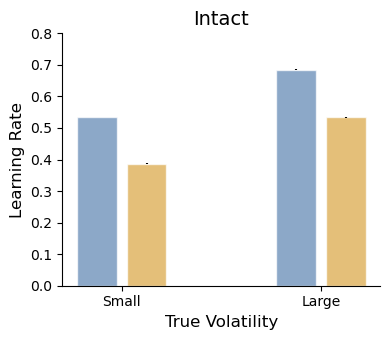

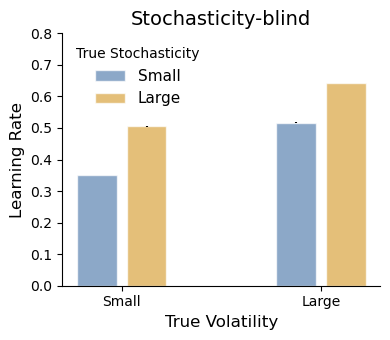

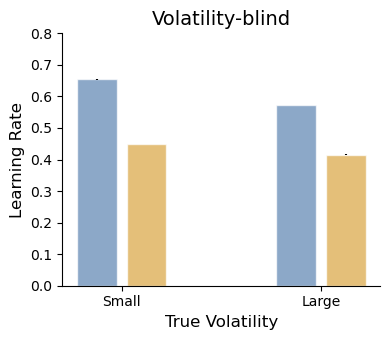

In [42]:
# Load MATLAB file
mat = sio.loadmat(os.path.join(base_dir, "..", "mat_data","experiment_sim", "sim_lesioned.mat"), squeeze_me=True, struct_as_record=False)
sim = mat["sim"]
ma = np.asarray(sim.ma, dtype=float)
mv = np.asarray(sim.mv, dtype=float)
ms = np.asarray(sim.ms, dtype=float)
ea = np.asarray(sim.ea, dtype=float)
ev = np.asarray(sim.ev, dtype=float)
es = np.asarray(sim.es, dtype=float)
group_names = ["Intact", "Stochasticity-blind", "Volatility-blind"] 
mean_lr = {}
sem_lr = {}
for i, gname in enumerate(group_names):
    mean_lr[gname] = ma[i, :]
    sem_lr[gname]  = ea[i, :]
    
# Plot: Intact simulation learning rate
config_c = config.copy()
config_c.update({
    'XLABEL': 'True Volatility',
    'X_TICK_LABEL': ['Small', 'Large'],
    'YLABEL': 'Learning Rate',
    'YLIM': (0, 0.8),
    'LEGEND_TITLE': 'True Stochasticity',
    'GROUP_LABEL': ['Small', 'Large'],
    'GROUP_COLOR': size_colors,
    'SHOW_LEGEND': False,
    'TITLE': group_names[0],
    'SAVE_PATH': save_path + "Figure1_intact_sim_lr_bird.png",
})
# Reshape 1D arrays to 2D: (n_groups=2, n_effects=2)
betas = np.array([mean_lr[group_names[0]][0:2], mean_lr[group_names[0]][2:4]])
ses = np.array([sem_lr[group_names[0]][0:2], sem_lr[group_names[0]][2:4]])
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Stochasticity-blind simulation learning rate
config_c.update({
    'SHOW_LEGEND': True,
    'TITLE': group_names[1],
    'SAVE_PATH': save_path + "Figure1_sto_blind_sim_lr_bird.png",
})
betas = np.array([mean_lr[group_names[1]][0:2], mean_lr[group_names[1]][2:4]])
ses = np.array([sem_lr[group_names[1]][0:2], sem_lr[group_names[1]][2:4]])
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Volatility-blind simulation learning rate
config_c.update({
    'SHOW_LEGEND': False,
    'TITLE': group_names[2],
    'SAVE_PATH': save_path + "Figure1_vol_blind_sim_lr_bird.png"
})
betas = np.array([mean_lr[group_names[2]][0:2], mean_lr[group_names[2]][2:4]])
ses = np.array([sem_lr[group_names[2]][0:2], sem_lr[group_names[2]][2:4]])
fig_tb.plot_bars(betas, ses, config_c)

## Figure 2 Bird task model neutral lr, lr effects, and EFA

[0.6848094  0.71662997 0.63025409 0.65690625] (2532, 4)
[ 0.67214993 -0.11427903  0.05847272]


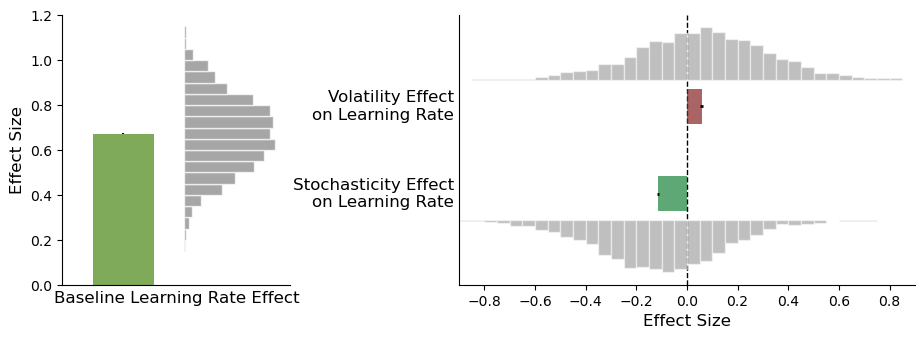

In [43]:
# Load .mat file
file_path = os.path.join(base_dir, "..","mat_data", "experiment_1", "model_neutral_bird.mat")
data = sio.loadmat(file_path)  
lr = data['lr']
print(np.mean(lr, axis=0), np.shape(lr))

# Plot: Effect size
# Preprocess data for learning rate
results = fig_tb.preprocess_effect_data(lr)
print(results['m_eff'])
config_c = config.copy()
config_c.update({
    'XLIM': (-0.9, 0.9), 
    'XLABEL': 'Effect Size',
    'YLIM2': (0, 1.2),
    'YLABEL': ['Baseline Learning Rate Effect', 
                'Stochasticity Effect\non Learning Rate',
                'Volatility Effect\non Learning Rate'],
    'GROUP_COLOR': eff_colors,
    'BAR_WIDTH': .2,
    'SAVE_PATH': save_path + "Figure2_mn_lr_effs_bird.png",
})
fig_tb.plot_effect_size_with_distribution(results, config_c)

In [44]:
# Load factor analysis results
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_1", "fa_score_ex2_factors2_bird.mat")
data = sio.loadmat(file_path)  
eigvals = data['eigvals'].flatten()
loadings = data['loadings']
fields = [str(x.flatten()[0]) if hasattr(x, 'flatten') else str(x) for x in np.array(data['field_names']).flatten()]

print(loadings.shape)
survey_groups, surveys_legend, survey_colors = fig_tb.survey_field_preprocess(fields)
fa1_loadings, fa2_loadings, primary_factors = fig_tb.summarize_survey_primary_factors(loadings, fields, survey_groups, aggfunc=np.mean, absolute=False)
print('FA1:', fa1_loadings)
print('FA2:', fa2_loadings)
print('Primary Factors:', primary_factors)

(188, 2)
FA1: OrderedDict([('pswq8', {'mean': 0.829, 'sd': 0.0434}), ('gad7', {'mean': 0.777, 'sd': 0.109}), ('dass21', {'mean': 0.672, 'sd': 0.125}), ('phq9', {'mean': 0.663, 'sd': 0.149}), ('ius12', {'mean': 0.532, 'sd': 0.158}), ('dsm23', {'mean': 0.513, 'sd': 0.27}), ('bis8', {'mean': 0.294, 'sd': 0.143}), ('cbs7', {'mean': 0.265, 'sd': 0.0956}), ('eat26', {'mean': 0.259, 'sd': 0.167}), ('cape15', {'mean': 0.229, 'sd': 0.121}), ('yboc', {'mean': 0.193, 'sd': 0.064}), ('pvp9', {'mean': 0.121, 'sd': 0.0423}), ('audit10', {'mean': 0.0751, 'sd': 0.0663}), ('lbt2', {'mean': -0.0247, 'sd': 0.0145}), ('gbq21', {'mean': -0.244, 'sd': 0.0711})])
FA2: OrderedDict([('gbq21', {'mean': 0.718, 'sd': 0.0803}), ('lbt2', {'mean': 0.412, 'sd': 0.0829}), ('yboc', {'mean': 0.27, 'sd': 0.031}), ('pvp9', {'mean': 0.219, 'sd': 0.0461}), ('cape15', {'mean': 0.219, 'sd': 0.0505}), ('cbs7', {'mean': 0.214, 'sd': 0.0588}), ('audit10', {'mean': 0.209, 'sd': 0.0356}), ('eat26', {'mean': 0.0502, 'sd': 0.0501}),

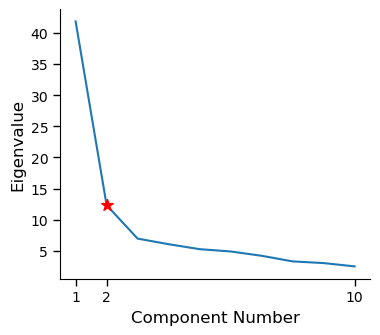

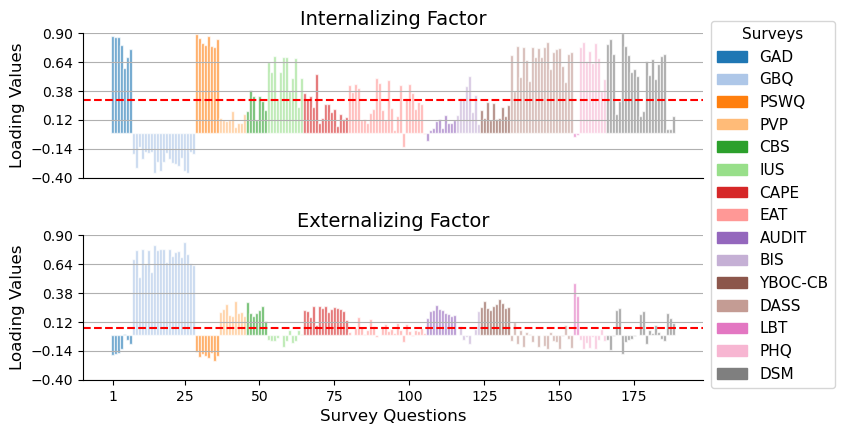

In [45]:
# Plot: Scree plot
config_c = config.copy()
n_points = 10
config_c.update({
    'N_POINTS': n_points,
    'XLABEL': 'Component Number',
    'XLIM': (0.5, n_points + 0.5),
    'YLABEL': 'Eigenvalue',
    'SAVE_PATH': save_path + "Figure2_fa_scree_bird.png",
})
fig_tb.plot_scree(eigvals, config_c)

# Plot: Factor loadings plot
config_c = config.copy()
config_c.update({
    'FIGSIZE': (8, 4.5),
    'XLABEL': 'Survey Questions',
    'X_TICK_INTERVAL': 25,
    'YLABEL': 'Loading Values',
    'YLIM': (-0.4, 0.9),
    'FACTOR_TITLES': ['Internalizing Factor', 'Externalizing Factor'],
    'BAR_WIDTH': 1,
    'SAVE_PATH': save_path + "Figure2_fa_loadings_bird.png",
})
fig_tb.plot_grouped_loadings(
    loadings=loadings,               # np.ndarray shape (200,2)
    survey_groups=survey_groups,     # {'gad7_Q01': 'gad7', 'gad7_Q02': 'gad7', ...}
    surveys_legend=surveys_legend,   # ['GAD', 'GBQ', 'PSWQ'...]
    survey_colors=survey_colors,     # {'gad7': (c1), ...}
    config=config_c
)

## Figure 3 Bird task model neutral with FA score by critical value groups

['Stochasticity-blind', 'Intact', 'Volatility-blind']
Intact Mean LR: [0.6625729  0.79581938 0.49406959 0.64402704]
Stochasticity-blind Mean LR: [0.50628542 0.68472597 0.65275484 0.75179335]
Volatility-blind Mean LR: [0.87660659 0.70282389 0.67888673 0.54212204]
Intact SEM LR: [0.00827176 0.00740447 0.0074165  0.00784469]
Stochasticity-blind SEM LR: [0.00832475 0.00847636 0.00901106 0.00787703]
Volatility-blind SEM LR: [0.01183643 0.01092847 0.011359   0.01027266]


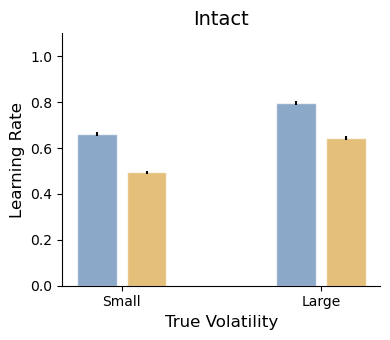

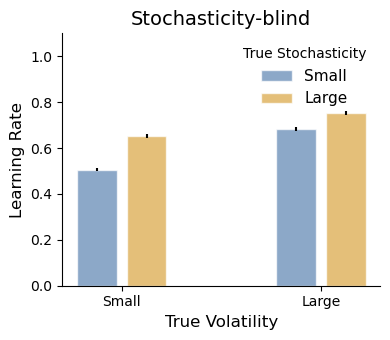

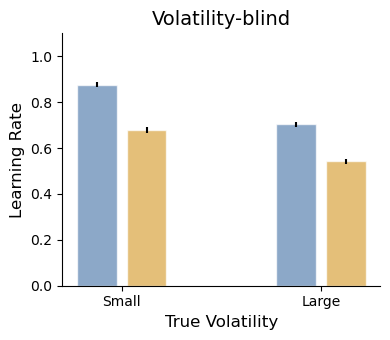

In [46]:
# Load learning rate grouping results
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_1", "critical_value_grouping_fascore_bird.mat")
data = sio.loadmat(file_path)  
group_names = data['out']['grouping'][0,0]['group_names'][0,0].flatten()
group_names = [str(g) if isinstance(g, str) else g.item() for g in group_names]
lr_groups = data['out']['lr'][0,0]['groups'][0,0]
sto_blind = lr_groups['sto_blind'][0,0]
intact = lr_groups['intact'][0,0]
vol_blind = lr_groups['vol_blind'][0,0]
mean_intact = intact['mean_lr'][0,0][0]
mean_sto_blind  = sto_blind['mean_lr'][0,0][0]
mean_vol_blind  = vol_blind['mean_lr'][0,0][0]
sem_intact = intact['sem_lr'][0,0][0]
sem_sto_blind  = sto_blind['sem_lr'][0,0][0]
sem_vol_blind  = vol_blind['sem_lr'][0,0][0]

print(group_names)
print("Intact Mean LR:", mean_intact)
print("Stochasticity-blind Mean LR:", mean_sto_blind)
print("Volatility-blind Mean LR:", mean_vol_blind)
print("Intact SEM LR:", sem_intact)
print("Stochasticity-blind SEM LR:", sem_sto_blind)
print("Volatility-blind SEM LR:", sem_vol_blind)

# Plot: Intact MN learning rate
config_c = config.copy()
config_c.update({
    'LEGEND_TITLE': 'True Stochasticity',
    'XLABEL': 'True Volatility',
    'X_TICK_LABEL': ['Small', 'Large'],
    'YLABEL': 'Learning Rate',
    'YLIM': (0, 1.1),
    'SHOW_LEGEND': False,
    'GROUP_LABEL': ['Small', 'Large'],
    'GROUP_COLOR': size_colors,
    'TITLE': group_names[1],
    'SAVE_PATH': save_path + "Figure3_intact_mn_lr_bird.png",
})
# Reshape 1D arrays to 2D: (n_groups=2, n_effects=2)
betas = np.array([mean_intact[0:2], mean_intact[2:4]])
ses = np.array([sem_intact[0:2], sem_intact[2:4]])
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Stochasticity-blind MN learning rate
config_c.update({
    'SHOW_LEGEND': True,
    'TITLE': group_names[0],
    'SAVE_PATH': save_path + "Figure3_sto_blind_mn_lr_bird.png",
})
betas = np.array([mean_sto_blind[0:2], mean_sto_blind[2:4]])
ses = np.array([sem_sto_blind[0:2], sem_sto_blind[2:4]])
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Volatility-blind MN learning rate
config_c.update({
    'SHOW_LEGEND': False,
    'TITLE': group_names[2],
    'SAVE_PATH': save_path + "Figure3_vol_blind_mn_lr_bird.png"
})
betas = np.array([mean_vol_blind[0:2], mean_vol_blind[2:4]])
ses = np.array([sem_vol_blind[0:2], sem_vol_blind[2:4]])
fig_tb.plot_bars(betas, ses, config_c)

['Stochasticity-blind', 'Intact', 'Volatility-blind'] 
 ['Factor 1', 'Factor 2', 'F1 - F2']
Means shape: (3, 3)
SEM shape: (3, 3)
P-values shape: (3, 1)
Factor means: [[ 0.06807504 -0.03153023 -0.1311527 ]
 [-0.12904794  0.01318437  0.11604178]
 [ 0.19712299 -0.04471461 -0.24719448]]


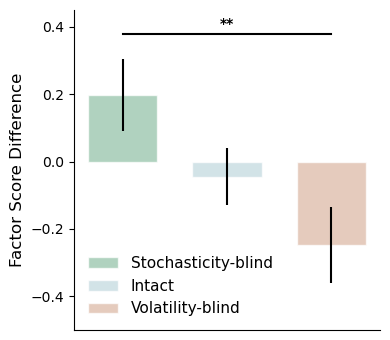

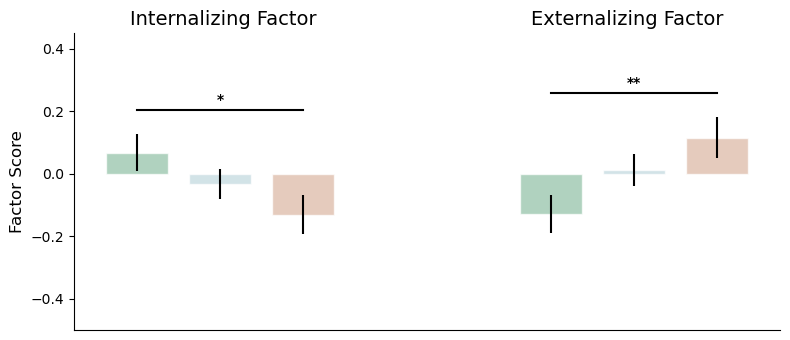

In [47]:
# Extract variables
group_names = data['out']['factors'][0,0]['group_names'][0,0].flatten()
group_names = [str(g) if isinstance(g, str) else g.item() for g in group_names]
factor_names = data['out']['factors'][0,0]['names'][0,0].flatten()
factor_names = [str(g) if isinstance(g, str) else g.item() for g in factor_names]
print(group_names, '\n', factor_names)
factor_names = ['Internalizing Factor', 'Externalizing Factor', 'Factor Score Difference']

# Extract means and standard errors from between-group analysis
between = data['out']['factors'][0,0]['between'][0,0]
# Shape: (n_factors=3, n_groups=3) where factors are [F1, F2, F1-F2] and groups are [sto_blind, intact, vol_blind]
m = between['mean'][0,0]  # means (3 factors, 3 groups)
s = between['se'][0,0]    # standard errors (3 factors, 3 groups)

# Extract p-values for pairwise comparisons (sto_vs_vol)
sto_vs_vol_p = between['sto_vs_vol'][0,0]['p'][0,0]  # p-values for each factor

print(f"Means shape: {m.shape}")
print(f"SEM shape: {s.shape}")
print(f"P-values shape: {sto_vs_vol_p.shape}")
print(f"Factor means: {m}")

# First panel: Factor Score Difference only
config_c = config.copy()
config_c.update({
    'FIGSIZE': (4, 3.5),
    'YLABEL': factor_names[2],
    'YLIM': (-0.5, 0.45),
    'GROUP_LABEL': group_names,
    'GROUP_COLOR': group_colors,
    'BAR_WIDTH': 0.05,
    'BAR_SPACING': 0.075,
    'P_STRICT': 0.01,
    'P_LENIENT': 0.05,
    'PAIRWISE_COMPARISONS': [(0, 0, 2, sto_vs_vol_p[2])],
    'PAIRWISE_LINE_Y_OFFSET': 0.08,
    'SAVE_PATH': save_path + 'Figure3_grouped_factor_diff_bird.png',
})
fig_tb.plot_bars(m[[2], :].T, s[[2], :].T, config_c)

# Second panel: Internalizing + Externalizing factors
config_c.update({
    'FIGSIZE': (8, 3.5),
    'YLABEL': 'Factor Score',
    'TITLE': factor_names[0] + " "*35 + factor_names[1],
    'BAR_WIDTH': 0.15,
    'BAR_SPACING': 0.20,
    'SHOW_LEGEND': False,
    'PAIRWISE_COMPARISONS': [
        (0, 0, 2, sto_vs_vol_p[0]),
        (1, 0, 2, sto_vs_vol_p[1]),
    ],
    'SAVE_PATH': save_path + 'Figure3_grouped_factor_int_ext_bird.png',
})
fig_tb.plot_bars(m[:2, :].T, s[:2, :].T, config_c)



Outlier report:
  Stochasticity-blind: discarded 4 outlier(s), kept 345
  Intact: discarded 15 outlier(s), kept 511
  Volatility-blind: discarded 5 outlier(s), kept 310


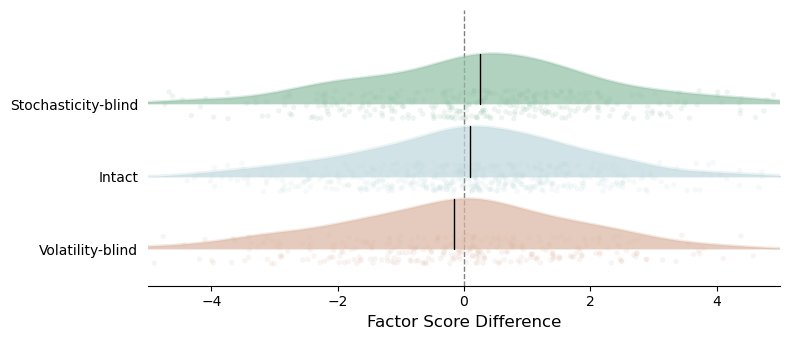

In [48]:
# Extract means and standard errors from between-group analysis
between = data['out']['factors'][0,0]['between'][0,0]
# Shape: (n_factors=3, n_groups=3) where factors are [F1, F2, F1-F2] and groups are [sto_blind, intact, vol_blind]
values = between['values'][0,0]  # values (3 factors, 3 groups)

fa1_values = values[0, :]
fa1_stomal = fa1_values[0].flatten()
fa1_intact = fa1_values[1].flatten()
fa1_volmal = fa1_values[2].flatten()

fa2_values = values[1, :]
fa2_stomal = fa2_values[0].flatten()
fa2_intact = fa2_values[1].flatten()
fa2_volmal = fa2_values[2].flatten()

fa_diff_values = values[2, :]
fa_diff_stomal = fa_diff_values[0].flatten()
fa_diff_intact = fa_diff_values[1].flatten()
fa_diff_volmal = fa_diff_values[2].flatten()

config_c = config.copy()
config_c.update({
    'FIGSIZE': (8, 3.5),
    'GROUP_LABEL': ['Stochasticity-blind', 'Intact', 'Volatility-blind'],
    'GROUP_COLOR': group_colors,
    'XLABEL': 'Factor Score Difference',
    'YLABEL': None,
    'XLIM': (-5, 5),
    'DISCARD_OUTLIERS': True,
    'OUTLIER_METHOD': 'iqr',
    'IQR_K': 1.5,
    'PRINT_OUTLIERS': True,
    'SHOW_POINTS': True,
    'POINT_ALPHA': 0.15,
    'POINT_SIZE': 15,
    'VIOLIN_SCALE': 0.7,
    'SUMMARY_MARKER': 'mean',   # or 'mean'
    'SUMMARY_LINE_HEIGHT': 0.7,
    'ZERO_LINE': True,
    'SAVE_PATH': save_path + 'Figure3_half_violin_fa_diff_bird.png',
})
fig_tb.plot_half_violin(
    [fa_diff_stomal, fa_diff_intact, fa_diff_volmal],
    config_c
)



## Figure 4 (Sea lion and turtle distr-HMM plots)

Sealion: [0.53081604 0.61640443 0.47615201 0.54061092]


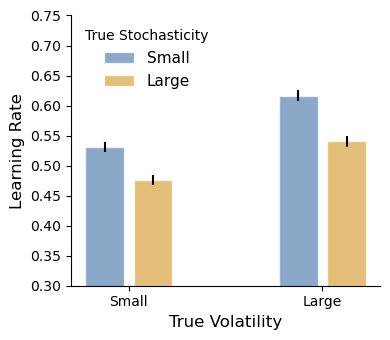

Turtle: [0.58956583 0.68772083 0.53824383 0.61649598]


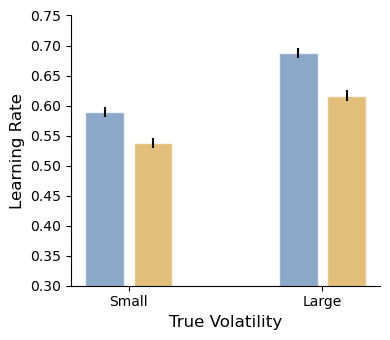

In [49]:
# Load .mat file
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_2", "distrHMM_rho_fit_params_sealion_aligned.mat")
data = sio.loadmat(file_path)  
lr_sealion = data['lr']
print("Sealion: {}".format(np.mean(lr_sealion, axis=0)))
# Plot: Learning rate coefficients
config_c = config.copy()
config_c.update({
    'XLABEL': 'True Volatility',
    'X_TICK_LABEL': ['Small', 'Large'],
    'YLABEL': 'Learning Rate',
    'YLIM': (0.3, 0.75),
    'LEGEND_TITLE': 'True Stochasticity',
    'GROUP_LABEL': ['Small', 'Large'],
    'GROUP_COLOR': size_colors,
    'SHOW_LEGEND': True,
    'LEGEND_LOC': 'upper left',
    'SAVE_PATH': save_path + "Figure4_distr_lr_sealion.png",
})
mean_lr = np.mean(lr_sealion, axis=0)
se_lr = fig_tb.serr(lr_sealion)
betas = np.array([mean_lr[0:2], mean_lr[2:4]])
ses = np.array([se_lr[0:2], se_lr[2:4]])
fig_tb.plot_bars(betas, ses, config_c)

# Load .mat file
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_2", "distrHMM_rho_fit_params_turtle_aligned.mat")
data = sio.loadmat(file_path)  
lr_turtle = data['lr']
print("Turtle: {}".format(np.mean(lr_turtle, axis=0)))
# Plot: Learning rate coefficients
config_c.update({
    'SHOW_LEGEND': False,
    'SAVE_PATH': save_path + "Figure4_distr_lr_turtle.png",
})
mean_lr = np.mean(lr_turtle, axis=0)
se_lr = fig_tb.serr(lr_turtle)
betas = np.array([mean_lr[0:2], mean_lr[2:4]])
ses = np.array([se_lr[0:2], se_lr[2:4]])
fig_tb.plot_bars(betas, ses, config_c)



## Figure 5 Sea lion and turtle distr lr effects and valence effects with factors glm

Sealion: [ 0.54099585 -0.13045754  0.15004731]
Turtle: [ 0.60800662 -0.12254686  0.17640715]
Valence: [-0.06701077 -0.00791069 -0.02635984]


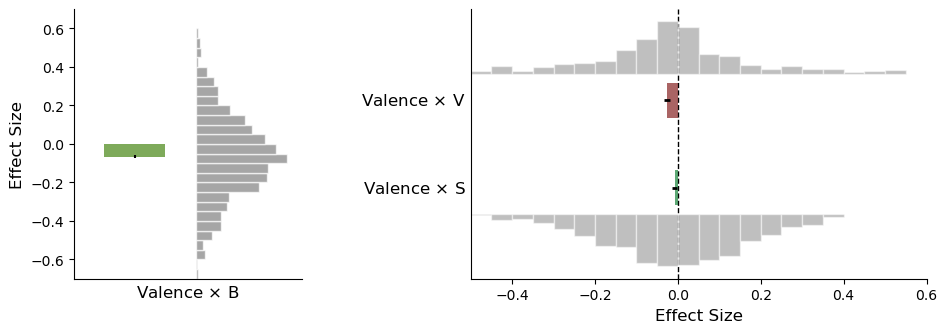

In [50]:
# Preprocess data for learning rate
results_sealion = fig_tb.preprocess_effect_data(lr_sealion)
print("Sealion: {}".format(results_sealion['m_eff']))
results_turtle = fig_tb.preprocess_effect_data(lr_turtle)
print("Turtle: {}".format(results_turtle['m_eff']))

results_valence = {
    key: results_sealion[key] - results_turtle[key] 
    for key in results_sealion.keys()
}
results_valence['sem_eff'] = fig_tb.serr(results_sealion['eff'] - results_turtle['eff'])
print("Valence: {}".format(results_valence['m_eff']))
# Plot: Learning rate effect valence (Sealion - Turtle)
config_c = config.copy()
config_c.update({
    'XLIM': (-0.5, 0.6), 
    'XLABEL': 'Effect Size',
    'YLIM2': (-0.7, 0.7),
    'YLABEL': [r'Valence $\times$ B', r'Valence $\times$ S', r'Valence $\times$ V'],
    'GROUP_COLOR': eff_colors,
    'SAVE_PATH': save_path + "Figure5_distr_effs_valence.png",
})
fig_tb.plot_effect_size_with_distribution(results_valence, config_c)


Significance report:

Internalizing Factor:
  Effect Baseline: p=0.037  (*)
  Effect Stochasticity: p=0.264
  Effect Volatility: p=0.871
  Effect Valence $\times$ Baseline: p=0.0276  (*)
  Effect Valence $\times$ Stochasticity: p=0.0842
  Effect Valence $\times$ Volatility: p=0.545

Externalizing Factor:
  Effect Baseline: p=0.812
  Effect Stochasticity: p=0.613
  Effect Volatility: p=0.00166  (**)
  Effect Valence $\times$ Baseline: p=0.173
  Effect Valence $\times$ Stochasticity: p=0.659
  Effect Valence $\times$ Volatility: p=0.368


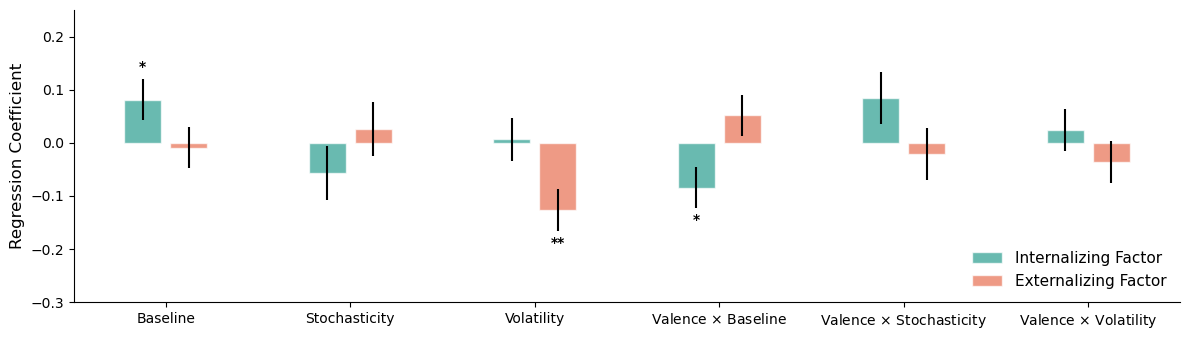

In [51]:
matpath = os.path.join(base_dir, "..", "mat_data", "experiment_2", 'factor_glm_distr_lr_valence.mat')
_res = fig_tb.load_glm_results(matpath)
cols = np.r_[1:4, 5:8]
betas = np.vstack([_res['glm_beta'][0][cols], _res['glm_beta'][1][cols]])
ses = np.vstack([_res['glm_se'][0][cols], _res['glm_se'][1][cols]])
ps = np.vstack([_res['glm_p'][0][cols], _res['glm_p'][1][cols]])

# Plot: Regression coefficients of factor 1 and factor 2 for valence effect (Sealion - Turtle)
config_c = config.copy()
config_c.update({
    'FIGSIZE': (12, 3.5),
    'X_TICK_LABEL': ['Baseline', 'Stochasticity', 'Volatility', r'Valence $\times$ Baseline', 
                     r'Valence $\times$ Stochasticity', r'Valence $\times$ Volatility'],
    'YLABEL': 'Regression Coefficient',
    'YLIM': (-0.3, 0.25),
    'SHOW_LEGEND': True,
    'LEGEND_LOC': 'lower right',
    'GROUP_LABEL': factor_names[:2],              # Rows: Factor 1, Factor 2
    'GROUP_COLOR': factor_colors[:2],  # Color per factor (group)
    'BAR_WIDTH': 0.2,
    'P_VALUES': ps,
    'P_STRICT': 0.005,
    'P_LENIENT': 0.05,
    'SAVE_PATH': save_path + "Figure5_fa_glm_distr_valence.png"
})
fig_tb.plot_bars(betas, ses, config_c)


Significance report:

Internalizing:
  Effect Baseline: p=0.73
  Effect Stochasticity: p=0.687
  Effect Volatility: p=0.494

Externalizing:
  Effect Baseline: p=0.64
  Effect Stochasticity: p=0.883
  Effect Volatility: p=0.000623  (**)


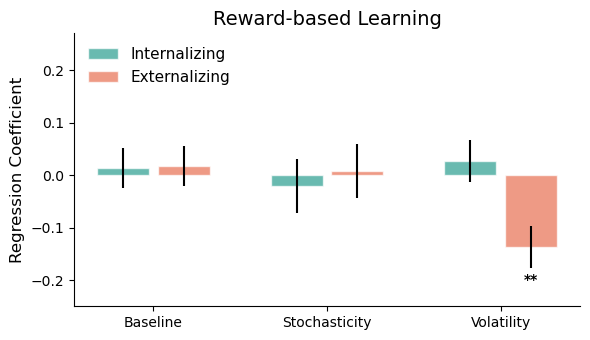


Significance report:

Internalizing:
  Effect Baseline: p=0.00456  (**)
  Effect Stochasticity: p=0.0322  (*)
  Effect Volatility: p=0.793

Externalizing:
  Effect Baseline: p=0.266
  Effect Stochasticity: p=0.485
  Effect Volatility: p=0.035  (*)


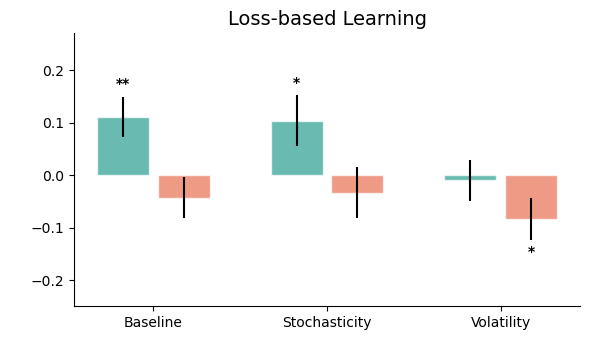

In [52]:
# Import GLM results from aligned sea lion and turtle datasets
matpath = os.path.join(base_dir, "..", "mat_data", "experiment_2", 'factor_glm_distr_lr_sealion_aligned.mat')
sealion_res = fig_tb.load_glm_results(matpath)

matpath = os.path.join(base_dir, "..", "mat_data", "experiment_2", 'factor_glm_distr_lr_turtle_aligned.mat')
turtle_res = fig_tb.load_glm_results(matpath)

# Plot: Sea Lion - Regression coefficients with factors as legend
betas = np.array([sealion_res['glm_beta'][0][1:4], sealion_res['glm_beta'][1][1:4]])
ses = np.array([sealion_res['glm_se'][0][1:4], sealion_res['glm_se'][1][1:4]])
ps = np.array([sealion_res['glm_p'][0][1:4], sealion_res['glm_p'][1][1:4]])
config_c = config.copy()
config_c.update({
    'FIGSIZE': (6, 3.5),
    'X_TICK_LABEL': ['Baseline', 'Stochasticity', 'Volatility'],
    'YLABEL': 'Regression Coefficient',
    'YLIM': (-0.25, 0.27),
    'SHOW_LEGEND': True,
    'LEGEND_LOC': 'upper left',
    'GROUP_LABEL': ['Internalizing', 'Externalizing'],
    'GROUP_COLOR': factor_colors[:2],
    'BAR_WIDTH': 0.3,
    'BAR_SPACING': 0.35,
    'P_VALUES': ps,
    'P_STRICT': 0.005,
    'P_LENIENT': 0.05,
    'TITLE': 'Reward-based Learning',
    'SAVE_PATH': save_path + "Figure5_sealion_glm_distr_cmp.png",
})
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Turtle - Regression coefficients with factors as legend
betas = np.array([turtle_res['glm_beta'][0][1:4], turtle_res['glm_beta'][1][1:4]])
ses = np.array([turtle_res['glm_se'][0][1:4], turtle_res['glm_se'][1][1:4]])
ps = np.array([turtle_res['glm_p'][0][1:4], turtle_res['glm_p'][1][1:4]])
config_c.update({
    'YLABEL': ' ',
    'SHOW_LEGEND': False,
    'P_VALUES': ps,
    'TITLE': 'Loss-based Learning',
    'SAVE_PATH': save_path + "Figure5_turtle_glm_distr_cmp.png",
})
fig_tb.plot_bars(betas, ses, config_c)


## Supplementary Plots 

## Bird task factor score x mn lr effect glm


Significance report:
  Effect Internalizing: p=0.000263  (**)
  Effect Externalizing: p=0.964


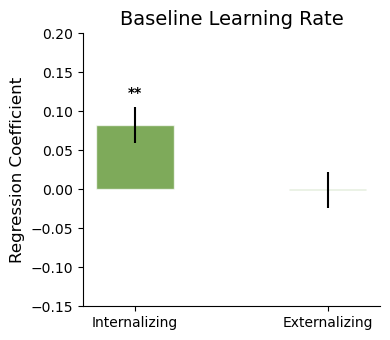


Significance report:
  Effect Internalizing: p=0.434
  Effect Externalizing: p=0.236


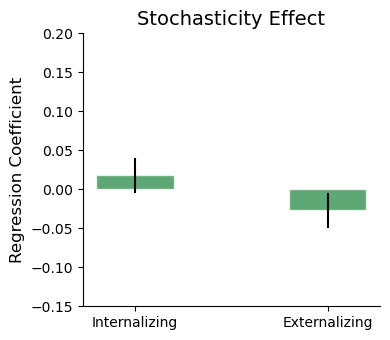


Significance report:
  Effect Internalizing: p=0.487
  Effect Externalizing: p=0.001  (*)


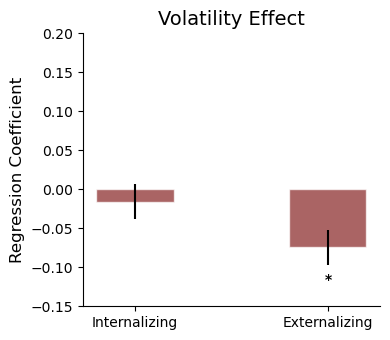

In [53]:
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_1", 'mn_lr_glm_factor_bird.mat')
mn_glm = sio.loadmat(file_path)
st = mn_glm['st'][0, 0]

# Extract modelA results (Effect ~ Factor 1 + Factor 2)
# coeff/se/p structure: [Factor1, Factor2, Intercept]
factor_labels = ['Internalizing', 'Externalizing']

# Plot: Baseline LR 
effect_data = st['modelA'][0, 0]['effect'][0, 0]
coeff = effect_data['coeff'][0]  # [Factor1, Factor2, Intercept]
se = effect_data['se'][0]
p = effect_data['p'][0]

betas = np.array([[coeff[0], coeff[1]]])  # Shape (1, 2)
ses = np.array([[se[0], se[1]]])
ps = np.array([[p[0], p[1]]])

config_c = config.copy()
config_c.update({
    'X_TICK_LABEL': factor_labels,
    'YLABEL': 'Regression Coefficient',
    'YLIM': (-0.15, 0.2),
    'SHOW_LEGEND': False,
    'GROUP_COLOR': [eff_colors[0]],  # Baseline color
    'BAR_WIDTH': 0.4,
    'P_VALUES': ps,
    'P_STRICT': 0.001,
    'P_LENIENT': 0.05,
    'TITLE': 'Baseline Learning Rate',
    'SAVE_PATH': save_path + "FigureSupp_mn_lr_baseline_glm_bird.png",
})
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Stochasticity Effect 
effect_data = st['modelA'][0, 0]['effect'][0, 1]
coeff = effect_data['coeff'][0]
se = effect_data['se'][0]
p = effect_data['p'][0]

betas = np.array([[coeff[0], coeff[1]]])
ses = np.array([[se[0], se[1]]])
ps = np.array([[p[0], p[1]]])

config_c.update({
    'GROUP_COLOR': [eff_colors[1]],  # Stochasticity color
    'P_VALUES': ps,
    'TITLE': 'Stochasticity Effect',
    'SAVE_PATH': save_path + "FigureSupp_mn_lr_sto_glm_bird.png",
})
fig_tb.plot_bars(betas, ses, config_c)

# Plot: Volatility Effect
effect_data = st['modelA'][0, 0]['effect'][0, 2]
coeff = effect_data['coeff'][0]
se = effect_data['se'][0]
p = effect_data['p'][0]

betas = np.array([[coeff[0], coeff[1]]])
ses = np.array([[se[0], se[1]]])
ps = np.array([[p[0], p[1]]])

config_c.update({
    'GROUP_COLOR': [eff_colors[2]],  # Volatility color
    'P_VALUES': ps,
    'TITLE': 'Volatility Effect',
    'SAVE_PATH': save_path + "FigureSupp_mn_lr_vol_glm_bird.png",
})
fig_tb.plot_bars(betas, ses, config_c)


Condition=b, factor=3
  OLS R² = 0.005, p = 2.937e-04
  Robust slope = 0.1343, p ≈ 6.611e-05
  Spearman ρ = 0.074, p = 2.016e-04


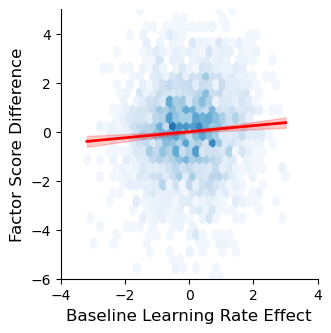


Condition=sto, factor=3
  OLS R² = 0.001, p = 5.352e-02
  Robust slope = 0.0625, p ≈ 6.616e-02
  Spearman ρ = 0.034, p = 8.915e-02


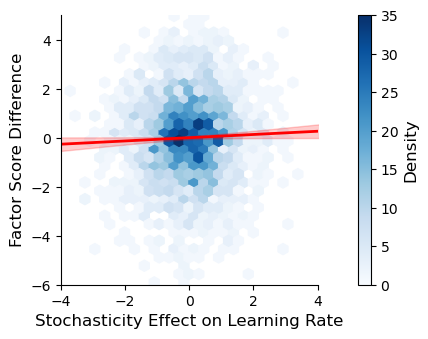


Condition=vol, factor=3
  OLS R² = 0.003, p = 1.094e-02
  Robust slope = 0.0628, p ≈ 6.477e-02
  Spearman ρ = 0.042, p = 3.319e-02


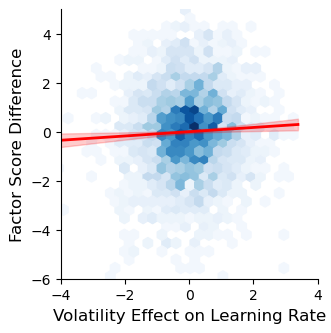

In [54]:
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_1", 'factor_glm_mn_lr_bird.mat')
_res = fig_tb.load_glm_results(file_path)

# Plot: Factor1 vs. Baseline regression density 
config_c = config.copy()
config_c.update({
    'XLABEL': 'Baseline Learning Rate Effect',
    'XLIM': (-4, 4),
    'YLABEL': 'Factor Score Difference',
    'YLIM': (-6, 5),
    'HEXBIN_VMAX': 35,
    'DENSITY_BAR': False,
    'SAVE_PATH': save_path + "FigureSupp_fa_diff_b_glm_reg_bird.png",
})
fig_tb.plot_regression_density(_res, 'b', 3, config_c) 

# Plot: Factor2 vs. Baseline regression density 
config_c.update({
    'XLABEL': 'Stochasticity Effect on Learning Rate',
    'DENSITY_BAR': True,
    'SAVE_PATH': save_path + "FigureSupp_fa_diff_sto_glm_reg_bird.png",
})
fig_tb.plot_regression_density(_res, 'sto', 3, config_c) 

# Plot 6: Factor2 vs. Volatility regression density 
config_c.update({
    'XLABEL': 'Volatility Effect on Learning Rate',
    'DENSITY_BAR': False,
    'SAVE_PATH': save_path + "FigureSupp_fa_diff_vol_glm_reg_bird.png",
})
fig_tb.plot_regression_density(_res, 'vol', 3, config_c) 

## Sea lion and turtle task lr effects

Sealion: [ 0.54099585 -0.13045754  0.15004731]


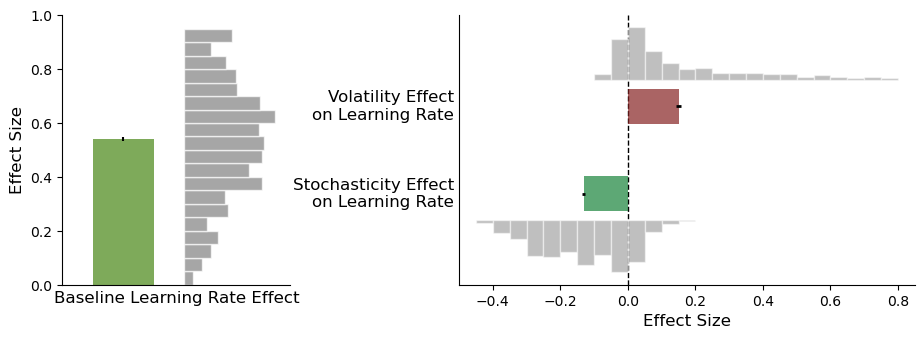

Turtle: [ 0.60800662 -0.12254686  0.17640715]


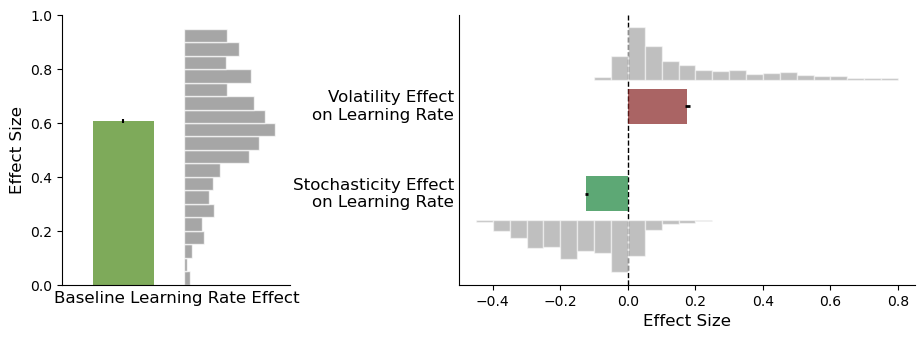

In [55]:
# Load .mat file
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_2", "distrHMM_rho_fit_params_sealion_aligned.mat")
data = sio.loadmat(file_path)  
lr_sealion = data['lr']
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_2", "distrHMM_rho_fit_params_turtle_aligned.mat")
data = sio.loadmat(file_path)  
lr_turtle = data['lr']

# Plot: Effect size
# Preprocess data for learning rate
results_sealion = fig_tb.preprocess_effect_data(lr_sealion)
print("Sealion: {}".format(results_sealion['m_eff']))
config_c = config.copy()
config_c.update({
    'XLIM': (-0.5, 0.85), 
    'XLABEL': 'Effect Size',
    'YLIM2': (0, 1),
    'YLABEL': ['Baseline Learning Rate Effect', 
                'Stochasticity Effect\non Learning Rate',
                'Volatility Effect\non Learning Rate'],
    'GROUP_COLOR': eff_colors,
    'SAVE_PATH': save_path + "FigureSupp_distr_effs_sealion.png",
})
fig_tb.plot_effect_size_with_distribution(results_sealion, config_c)

# Plot: Effect size
# Preprocess data for learning rate
results_turtle = fig_tb.preprocess_effect_data(lr_turtle)
print("Turtle: {}".format(results_turtle['m_eff']))
config_c.update({
    'SAVE_PATH': save_path + "FigureSupp_distr_effs_turtle.png",
})
fig_tb.plot_effect_size_with_distribution(results_turtle, config_c)

### Sea lion task & Turtle task pooled EFA

In [56]:
# Load factor analysis results
file_path = os.path.join(base_dir, "..", "mat_data", "experiment_2", "fa_score_pooled_ex2_factors2.mat")
data = sio.loadmat(file_path)  
eigvals = data['eigvals'].flatten()
loadings = data['loadings']
fields = [str(x.flatten()[0]) if hasattr(x, 'flatten') else str(x) for x in np.array(data['field_names']).flatten()]

print('Original loadings.shape:', loadings.shape)
print('Original loadings sample: \n', loadings[:5])  # Print first 5 rows for inspection
loadings_avg = loadings.reshape(2, 86, 2).mean(axis=0)
print('Average loadings.shape:', loadings_avg.shape)
print('Average loadings sample: \n', loadings_avg[:5])  # Print first 5 rows of averaged loadings for inspection

survey_groups, surveys_legend, survey_colors = fig_tb.survey_field_preprocess(fields)
fa1_loadings, fa2_loadings, primary_factors = fig_tb.summarize_survey_primary_factors(loadings, fields, survey_groups, aggfunc=np.mean, absolute=False)
print('FA1:', fa1_loadings)
print('FA2:', fa2_loadings)
print('Primary Factors:', primary_factors)

Original loadings.shape: (172, 2)
Original loadings sample: 
 [[ 0.81459621 -0.06788807]
 [ 0.80025602 -0.04691347]
 [ 0.83270631 -0.06926614]
 [ 0.67142987 -0.02379939]
 [ 0.44286444  0.02192005]]
Average loadings.shape: (86, 2)
Average loadings sample: 
 [[ 0.80431363 -0.06177838]
 [ 0.79374703 -0.05768569]
 [ 0.83448905 -0.06194403]
 [ 0.67432783 -0.02515074]
 [ 0.44821538  0.03399495]]
FA1: OrderedDict([('pswq8', {'mean': 0.901, 'sd': 0.0287}), ('gad7', {'mean': 0.7, 'sd': 0.136}), ('ius12', {'mean': 0.614, 'sd': 0.15}), ('yboc', {'mean': 0.221, 'sd': 0.0771}), ('cbs7', {'mean': 0.216, 'sd': 0.0908}), ('pvp9', {'mean': 0.169, 'sd': 0.0482}), ('audit10', {'mean': 0.0718, 'sd': 0.0701}), ('lbt2', {'mean': 0.0306, 'sd': 0.0131}), ('gbq21', {'mean': -0.105, 'sd': 0.0586})])
FA2: OrderedDict([('gbq21', {'mean': 0.645, 'sd': 0.0761}), ('lbt2', {'mean': 0.421, 'sd': 0.0472}), ('yboc', {'mean': 0.266, 'sd': 0.0323}), ('cbs7', {'mean': 0.221, 'sd': 0.0422}), ('audit10', {'mean': 0.186, 'sd'

/Users/Kary/anaconda3/envs/hmm/lib/python3.11/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


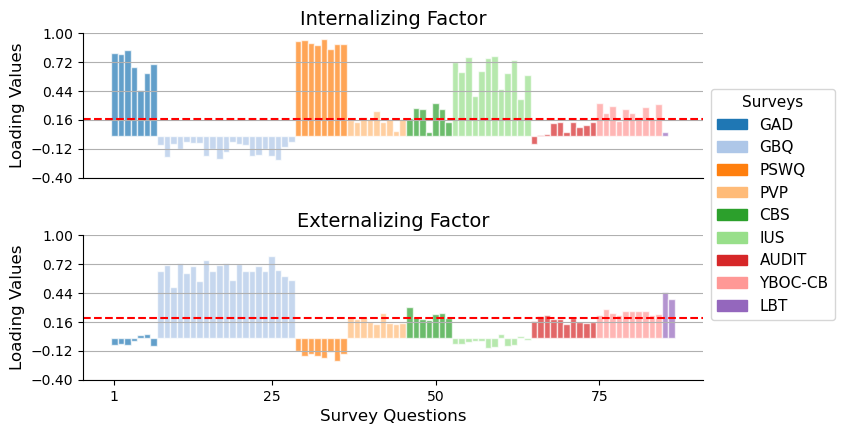

In [57]:
# Plot: Factor loadings plot (averaged across aligned questions)
config_c = config.copy()
config_c.update({
    'FIGSIZE': (8, 4.5),
    'XLABEL': 'Survey Questions',
    'X_TICK_INTERVAL': 25,
    'YLABEL': 'Loading Values',
    'YLIM': (-0.4, 1),
    'FACTOR_TITLES': ['Internalizing Factor', 'Externalizing Factor'],
    'BAR_WIDTH': 1,
    'SAVE_PATH': save_path + "FigureSupp_fa_loadings_pooled.png",
})
fig_tb.plot_grouped_loadings(
    loadings=loadings_avg,              
    survey_groups=survey_groups,     
    surveys_legend=surveys_legend,   
    survey_colors=survey_colors,  
    config=config_c
)

### Sea lion and turtle task factor glm regression


Condition=b, factor=3
  OLS R² = 0.002, p = 2.401e-01
  Robust slope = 0.0921, p ≈ 1.327e-01
  Spearman ρ = 0.057, p = 1.270e-01


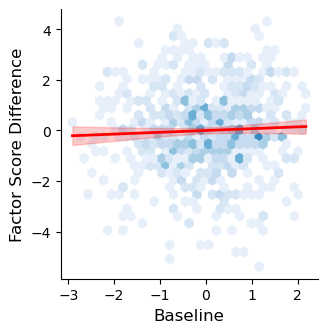


Condition=sto, factor=3
  OLS R² = 0.003, p = 1.120e-01
  Robust slope = -0.0486, p ≈ 4.297e-01
  Spearman ρ = -0.045, p = 2.289e-01


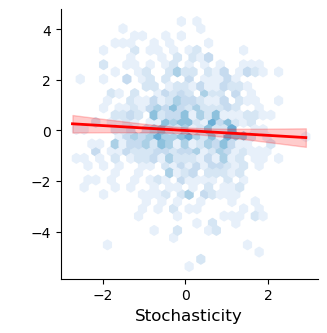


Condition=vol, factor=3
  OLS R² = 0.008, p = 1.669e-02
  Robust slope = 0.1204, p ≈ 5.163e-02
  Spearman ρ = 0.085, p = 2.160e-02


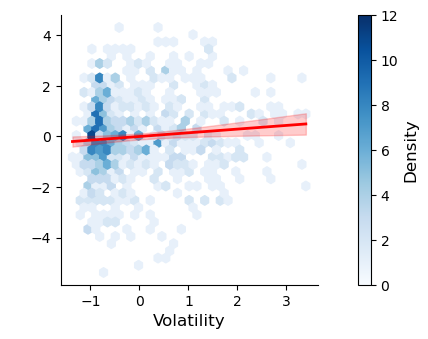


Condition=valence_b, factor=3
  OLS R² = 0.006, p = 4.547e-02
  Robust slope = -0.1043, p ≈ 9.073e-02
  Spearman ρ = -0.053, p = 1.523e-01


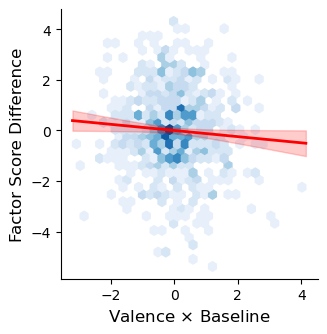


Condition=valence_s, factor=3
  OLS R² = 0.000, p = 9.308e-01
  Robust slope = -0.0100, p ≈ 8.713e-01
  Spearman ρ = -0.017, p = 6.461e-01


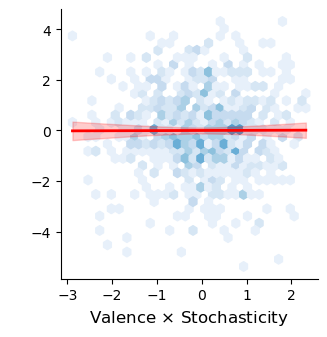


Condition=valence_v, factor=3
  OLS R² = 0.001, p = 4.153e-01
  Robust slope = 0.0526, p ≈ 3.933e-01
  Spearman ρ = 0.030, p = 4.178e-01


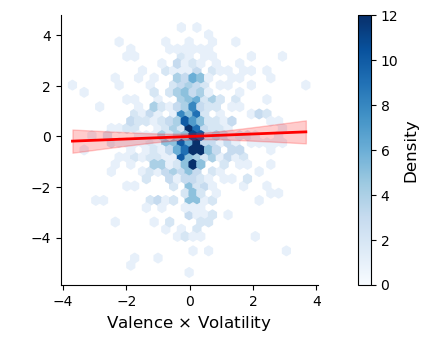

In [58]:
matpath = os.path.join(base_dir, "..", "mat_data", "experiment_2", 'factor_glm_distr_lr_valence.mat')
_res = fig_tb.load_glm_results(matpath)

# Plot: FactorDiff vs. Baseline regression density 
config_c = config.copy()
config_c.update({
    'XLABEL': 'Baseline',
    # 'XLIM': (-3, 3),
    'YLABEL': 'Factor Score Difference',
    # 'YLIM': (-2, 3),
    'HEXBIN_VMAX': 12,
    'DENSITY_BAR': False,
    'SAVE_PATH': save_path + "FigureSupp_fadiff_b_glm.png",
})
fig_tb.plot_regression_density(_res, 'b', 3, config_c) 

# Plot: FactorDiff vs. Stochasticity regression density 
config_c.update({
    'XLABEL': 'Stochasticity',
    'YLABEL': ' ',
    'SAVE_PATH': save_path + "FigureSupp_fadiff_sto_glm.png",
})
fig_tb.plot_regression_density(_res, 'sto', 3, config_c) 

# Plot: FactorDiff vs. Volatility regression density 
config_c.update({
    'XLABEL': 'Volatility',
    'YLABEL': ' ',
    'DENSITY_BAR': True,
    'SAVE_PATH': save_path + "FigureSupp_fadiff_vol_glm.png",
})
fig_tb.plot_regression_density(_res, 'vol', 3, config_c) 

# Plot: FactorDiff vs. Valence x Baseline regression density 
config_c.update({
    'XLABEL': r'Valence $\times$ Baseline',
    'YLABEL': 'Factor Score Difference',
    'DENSITY_BAR': False,
    'SAVE_PATH': save_path + "FigureSupp_fadiff_vb_glm.png",
})
fig_tb.plot_regression_density(_res, 'valence_b', 3, config_c) 

# Plot: FactorDiff vs. Valence x Stochasticity regression density 
config_c.update({
    'XLABEL': r'Valence $\times$ Stochasticity',
    'YLABEL': ' ',
    'SAVE_PATH': save_path + "FigureSupp_fadiff_vs_glm.png",
})
fig_tb.plot_regression_density(_res, 'valence_s', 3, config_c) 

# Plot: FactorDiff vs. Valence x Volatility regression density 
config_c.update({
    'XLABEL': r'Valence $\times$ Volatility',
    'YLABEL': ' ',
    'DENSITY_BAR': True,
    'SAVE_PATH': save_path + "FigureSupp_fadiff_vv_glm.png",
})
fig_tb.plot_regression_density(_res, 'valence_v', 3, config_c) 